# Task 5: Domestic vs. International Bias — Post-processing Score Blending

This notebook continues the Task 5 ethics analysis for the Expedia ranking model.

Bias investigated: **quality-of-service disparity between domestic and international searches**.

Mitigation tested here: **post-processing score blending**.

Idea:
- Train the original global LightGBM Ranker on all training searches.
- Train an international-specialist LightGBM Ranker only on international searches.
- For domestic validation searches, keep the global model score.
- For international validation searches, blend the global score with the international-specialist score:

\[
	ext{final score} = (1 - lpha) \cdot 	ext{global score} + lpha \cdot 	ext{international specialist score}
\]

We then tune `alpha` on the validation fold and compare the original model, full specialist replacement, and the best blended post-processing model.

In [1]:
# ---------------------------------------------------
# Cell 1: Imports and settings
# ---------------------------------------------------

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

RANDOM_STATE = 42
K = 5

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Imports loaded.")

Imports loaded.


In [2]:
# ---------------------------------------------------
# Cell 2: Load prepared Task 3 feature files
# ---------------------------------------------------
# These files should already exist from your Task 3 notebook.

train_feat = pd.read_parquet("data/train_features.parquet")
val_feat = pd.read_parquet("data/val_features.parquet")

print("Train features shape:", train_feat.shape)
print("Validation features shape:", val_feat.shape)

display(train_feat.head())

Train features shape: (3980039, 177)
Validation features shape: (978308, 177)


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool,relevance,visitor_hist_starrating_missing,visitor_hist_adr_usd_missing,srch_query_affinity_score_missing,orig_destination_distance_missing,prop_location_score2_missing,prop_review_score_missing,prop_review_score_is_zero,prop_starrating_is_zero,price_is_zero,price_below_1,price_below_10,price_usd_capped,price_usd_clipped,log_price_usd,log_price_usd_capped,log_price_usd_clipped,log_orig_destination_distance,total_guests,children_present,multi_room,domestic_search,log_booking_window,log_length_of_stay,last_minute_booking,long_booking_window,long_stay,is_4_star,is_5_star,high_review_score,search_month,search_quarter,search_dayofweek,search_hour,search_is_weekend,comp_rate_missing_count,comp_inv_missing_count,comp_pct_missing_count,comp_has_any_rate_data,comp_has_any_inv_data,comp_has_any_pct_data,comp_expedia_cheaper_count,comp_expedia_more_expensive_count,comp_same_price_count,comp_unavailable_count,comp_available_count,comp1_rate_missing,comp1_inv_missing,comp1_rate_percent_diff_missing,comp2_rate_missing,comp2_inv_missing,comp2_rate_percent_diff_missing,comp3_rate_missing,comp3_inv_missing,comp3_rate_percent_diff_missing,comp4_rate_missing,comp4_inv_missing,comp4_rate_percent_diff_missing,comp5_rate_missing,comp5_inv_missing,comp5_rate_percent_diff_missing,comp6_rate_missing,comp6_inv_missing,comp6_rate_percent_diff_missing,comp7_rate_missing,comp7_inv_missing,comp7_rate_percent_diff_missing,comp8_rate_missing,comp8_inv_missing,comp8_rate_percent_diff_missing,comp_no_rate_data_count,comp_no_inv_data_count,hotels_in_search,search_price_mean,search_price_median,search_price_min,search_price_max,price_diff_from_search_mean,price_diff_from_search_median,price_diff_from_search_min,price_ratio_to_search_mean,price_ratio_to_search_median,price_rank_in_search,price_pct_rank_in_search,search_log_price_mean,log_price_diff_from_search_mean,search_star_mean,search_star_max,star_diff_from_search_mean,star_diff_from_search_max,star_rank_in_search,star_pct_rank_in_search,search_review_mean,search_review_max,review_diff_from_search_mean,review_diff_from_search_max,review_rank_in_search,review_pct_rank_in_search,search_location1_mean,search_location2_mean,location1_diff_from_search_mean,location2_diff_from_search_mean,location2_rank_in_search,location2_pct_rank_in_search,search_promotion_rate,promotion_above_search_avg,prop_id_count,prop_id_mean_price,prop_id_median_price,prop_id_std_price,prop_id_mean_log_price,prop_id_mean_starrating,prop_id_mean_review_score,prop_id_mean_location_score1,prop_id_mean_location_score2,prop_id_mean_promotion_flag,dest_id_count,dest_id_mean_price,dest_id_median_price,dest_id_mean_starrating,dest_id_mean_review_score,dest_id_mean_location_score2,prop_dest_count
0,1,2013-04-04 08:32:15,12,187,-1.0,-1.0,219,893,3,3.5,1,2.83,0.0438,4.95,27,104.77,0,23246,1,0,4,0,1,1,-327.567505,392.559998,1,-2.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,-2.0,-2.0,0.0,0.0,0.0,0.0,0,NaN,0,0,1,1,1,1,0,0,0,0,0,0,0,104.769997,104.769997,4.661267,4.661267,4.661267,5.975234,4,0,0,0,0.0,0.693147,1,0,0,0,0,0,4,2,3,8,0,4,4,8,1,1,0,0,0,4,0,4,1,1,1,0

In [3]:
# ---------------------------------------------------
# Cell 3: Define domestic vs. international search groups
# ---------------------------------------------------
# domestic_search = 1 means visitor country equals hotel country.
# domestic_search = 0 means international / non-domestic search.

for df in [train_feat, val_feat]:
    df["domestic_search"] = (
        df["visitor_location_country_id"] == df["prop_country_id"]
    ).astype(np.int8)

print("Train domestic share:")
display(train_feat["domestic_search"].value_counts(normalize=True).rename(index={1: "Domestic", 0: "International"}))

print("Validation domestic share:")
display(val_feat["domestic_search"].value_counts(normalize=True).rename(index={1: "Domestic", 0: "International"}))

Train domestic share:


domestic_search
Domestic         0.63614
International    0.36386
Name: proportion, dtype: float64

Validation domestic share:


domestic_search
Domestic         0.646173
International    0.353827
Name: proportion, dtype: float64

In [4]:
# ---------------------------------------------------
# Cell 4: Basic group description on validation set
# ---------------------------------------------------

def describe_domestic_groups(df):
    rows = []
    for value, name in [(1, "Domestic searches"), (0, "International searches")]:
        g = df[df["domestic_search"] == value]
        rows.append({
            "domestic_group": name,
            "rows": len(g),
            "searches": g["srch_id"].nunique(),
            "click_rate": g["click_bool"].mean(),
            "booking_rate": g["booking_bool"].mean(),
            "mean_relevance": g["relevance"].mean(),
            "mean_price": g["price_usd"].mean(),
            "mean_distance": g["orig_destination_distance"].replace(-1, np.nan).mean()
        })
    return pd.DataFrame(rows)

group_description = describe_domestic_groups(val_feat)
display(group_description)

,domestic_group,rows,searches,click_rate,booking_rate,mean_relevance,mean_price,mean_distance
0,Domestic searches,632156,25781,0.044557,0.029085,0.160895,252.778940,504.181030
1,International searches,346152,14284,0.046251,0.027693,0.157024,540.085716,1853.067993


In [5]:
# ---------------------------------------------------
# Cell 5: Build feature list
# ---------------------------------------------------
# We do not use target-related columns or identifiers as model inputs.
# domestic_search is allowed as a feature because it can be computed in the test set.

NON_FEATURE_COLS = [
    "srch_id",
    "prop_id",
    "date_time",
    "click_bool",
    "booking_bool",
    "gross_bookings_usd",
    "position",
    "relevance"
]

feature_cols = [
    col for col in train_feat.columns
    if col not in NON_FEATURE_COLS
    and pd.api.types.is_numeric_dtype(train_feat[col])
]

missing_in_val = set(feature_cols) - set(val_feat.columns)
extra_in_val = set(val_feat.columns) - set(train_feat.columns)

print("Number of model features:", len(feature_cols))
print("Missing in validation:", missing_in_val)
print("Extra columns in validation compared with train:", len(extra_in_val))
print("First 40 features:")
print(feature_cols[:40])

Number of model features: 169
Missing in validation: set()
Extra columns in validation compared with train: 0
First 40 features:
['site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd', 'promotion_flag', 'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv', 'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv', 'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv', 'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv', 'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv', 'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv']


In [6]:
# ---------------------------------------------------
# Cell 6: Sort by search ID and build global matrices
# ---------------------------------------------------
# LightGBM Ranker requires rows to be sorted by group, with group sizes matching row order.

train_feat = train_feat.sort_values("srch_id").reset_index(drop=True)
val_feat = val_feat.sort_values("srch_id").reset_index(drop=True)

# Keep a row id for safe score replacement/blending later.
val_feat["row_id"] = np.arange(len(val_feat))

X_train = train_feat[feature_cols]
y_train = train_feat["relevance"].astype(int)
group_train = train_feat.groupby("srch_id").size().to_numpy()

X_val = val_feat[feature_cols]
y_val = val_feat["relevance"].astype(int)
group_val = val_feat.groupby("srch_id").size().to_numpy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Number of train search groups:", len(group_train))
print("Number of validation search groups:", len(group_val))

X_train: (3980039, 169)
X_val: (978308, 169)
Number of train search groups: 159836
Number of validation search groups: 39959


In [7]:
# ---------------------------------------------------
# Cell 7: Evaluation functions
# ---------------------------------------------------

def dcg_at_k(relevances, k=5):
    relevances = np.asarray(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    gains = (2 ** relevances - 1)
    return np.sum(gains / discounts)


def ndcg_at_k_for_group(y_true, y_score, k=5):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score)
    ranked_relevance = y_true[order]
    ideal_order = np.argsort(-y_true)
    ideal_relevance = y_true[ideal_order]
    dcg = dcg_at_k(ranked_relevance, k=k)
    idcg = dcg_at_k(ideal_relevance, k=k)
    if idcg == 0:
        return 0.0
    return dcg / idcg


def evaluate_domestic_international_bias(df, scores, model_name, k=5):
    """
    Evaluates ranking quality for domestic vs. international validation searches.

    Metrics:
    - mean NDCG@5 per group
    - booked Recall@5 per group
    - top-1 booked hit rate per group
    - mean rank of booked hotel per group
    """
    tmp = df[[
        "srch_id", "prop_id", "relevance", "booking_bool", "domestic_search"
    ]].copy()
    tmp["score"] = scores

    per_search_rows = []

    for srch_id, g in tmp.groupby("srch_id", sort=False):
        group_value = int(g["domestic_search"].iloc[0])
        y_true = g["relevance"].to_numpy()
        y_score = g["score"].to_numpy()
        ndcg = ndcg_at_k_for_group(y_true, y_score, k=k)

        ranked = g.sort_values("score", ascending=False).reset_index(drop=True)
        booked_positions = np.where(ranked["booking_bool"].to_numpy() == 1)[0]

        has_booking = len(booked_positions) > 0
        if has_booking:
            booked_rank = int(booked_positions[0]) + 1
            booked_in_topk = booked_rank <= k
            booked_at_top1 = booked_rank == 1
        else:
            booked_rank = np.nan
            booked_in_topk = np.nan
            booked_at_top1 = np.nan

        per_search_rows.append({
            "srch_id": srch_id,
            "domestic_search": group_value,
            "ndcg_at_5": ndcg,
            "has_booking": has_booking,
            "booked_rank": booked_rank,
            "booked_in_top5": booked_in_topk,
            "booked_at_top1": booked_at_top1
        })

    per_search = pd.DataFrame(per_search_rows)

    group_results = []
    for value, name in [(1, "Domestic searches"), (0, "International searches")]:
        g = per_search[per_search["domestic_search"] == value]
        g_booked = g[g["has_booking"]]

        group_results.append({
            "group": name,
            "num_searches": len(g),
            "num_booked_searches": len(g_booked),
            "mean_ndcg_at_5": g["ndcg_at_5"].mean(),
            "booked_recall_at_5": g_booked["booked_in_top5"].mean(),
            "booked_top1_hit_rate": g_booked["booked_at_top1"].mean(),
            "mean_booked_rank": g_booked["booked_rank"].mean()
        })

    group_results = pd.DataFrame(group_results)

    domestic = group_results[group_results["group"] == "Domestic searches"].iloc[0]
    international = group_results[group_results["group"] == "International searches"].iloc[0]

    metrics = {
        "model": model_name,
        "overall_ndcg@5": per_search["ndcg_at_5"].mean(),
        "domestic_ndcg@5": domestic["mean_ndcg_at_5"],
        "international_ndcg@5": international["mean_ndcg_at_5"],
        "international_minus_domestic_ndcg@5": international["mean_ndcg_at_5"] - domestic["mean_ndcg_at_5"],
        "domestic_booked_recall@5": domestic["booked_recall_at_5"],
        "international_booked_recall@5": international["booked_recall_at_5"],
        "international_minus_domestic_recall@5": international["booked_recall_at_5"] - domestic["booked_recall_at_5"],
        "domestic_top1_hit_rate": domestic["booked_top1_hit_rate"],
        "international_top1_hit_rate": international["booked_top1_hit_rate"],
        "domestic_mean_booked_rank": domestic["mean_booked_rank"],
        "international_mean_booked_rank": international["mean_booked_rank"],
        "num_domestic_searches": domestic["num_searches"],
        "num_international_searches": international["num_searches"],
        "num_domestic_booked_searches": domestic["num_booked_searches"],
        "num_international_booked_searches": international["num_booked_searches"]
    }

    return group_results, metrics, per_search

In [8]:
# ---------------------------------------------------
# Cell 8: Best model parameters from Task 4
# ---------------------------------------------------
# These are the best parameters from your Task 4 notebook.

best_parameters = {
    "num_leaves": 383,
    "learning_rate": 0.02,
    "min_child_samples": 900,
    "reg_lambda": 10.0,
    "reg_alpha": 0.0,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "n_estimators": 286
}

print(best_parameters)

{'num_leaves': 383, 'learning_rate': 0.02, 'min_child_samples': 900, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'subsample': 0.9, 'colsample_bytree': 0.8, 'n_estimators': 286}


In [9]:
# ---------------------------------------------------
# Cell 9: Train original global LightGBM Ranker
# ---------------------------------------------------
# This model is trained on all training searches.

global_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",

    n_estimators=best_parameters["n_estimators"],
    learning_rate=best_parameters["learning_rate"],
    num_leaves=best_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=best_parameters["min_child_samples"],

    reg_lambda=best_parameters["reg_lambda"],
    reg_alpha=best_parameters["reg_alpha"],
    subsample=best_parameters["subsample"],
    colsample_bytree=best_parameters["colsample_bytree"],

    random_state=RANDOM_STATE,
    n_jobs=-1
)

global_ranker.fit(
    X_train,
    y_train,
    group=group_train,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    eval_at=[5],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("Original global model trained.")

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.448840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16588
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 168
[100]	valid_0's ndcg@5: 0.383334
[200]	valid_0's ndcg@5: 0.385888
Original global model trained.


In [10]:
# ---------------------------------------------------
# Cell 10: Evaluate original global model
# ---------------------------------------------------

global_scores = global_ranker.predict(X_val)

global_group_results, global_metrics, global_per_search = evaluate_domestic_international_bias(
    val_feat,
    global_scores,
    model_name="Original global LightGBM Ranker",
    k=K
)

display(global_group_results)
display(pd.DataFrame([global_metrics]).T.rename(columns={0: "value"}))

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25721,18381,0.396768,0.605952,0.226974,6.461944
1,International searches,14238,9591,0.369792,0.571995,0.207590,6.999583


,value
model,Original global LightGBM Ranker
overall_ndcg@5,0.387156
domestic_ndcg@5,0.396768
international_ndcg@5,0.369792
international_minus_domestic_ndcg@5,-0.026976
domestic_booked_recall@5,0.605952
international_booked_recall@5,0.571995
international_minus_domestic_recall@5,-0.033957
domestic_top1_hit_rate,0.226974
international_top1_hit_rate,0.20759


In [11]:
# ---------------------------------------------------
# Cell 11: Prepare international-only training and validation data
# ---------------------------------------------------
# Specialist model: trained only on international / non-domestic searches.

train_int = train_feat[train_feat["domestic_search"] == 0].copy()
val_int = val_feat[val_feat["domestic_search"] == 0].copy()

train_int = train_int.sort_values("srch_id").reset_index(drop=True)
val_int = val_int.sort_values("srch_id").reset_index(drop=True)

X_train_int = train_int[feature_cols]
y_train_int = train_int["relevance"].astype(int)
group_train_int = train_int.groupby("srch_id").size().to_numpy()

X_val_int = val_int[feature_cols]
y_val_int = val_int["relevance"].astype(int)
group_val_int = val_int.groupby("srch_id").size().to_numpy()

print("International train rows:", X_train_int.shape)
print("International validation rows:", X_val_int.shape)
print("International train searches:", len(group_train_int))
print("International validation searches:", len(group_val_int))

International train rows: (1448177, 169)
International validation rows: (346152, 169)
International train searches: 59311
International validation searches: 14284


In [12]:
# ---------------------------------------------------
# Cell 12: Train international specialist ranker
# ---------------------------------------------------
# We start with the same main hyperparameters as the global model.
# Because this is a smaller training set, early stopping is useful here.

international_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",

    n_estimators=1000,
    learning_rate=best_parameters["learning_rate"],
    num_leaves=best_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=best_parameters["min_child_samples"],

    reg_lambda=best_parameters["reg_lambda"],
    reg_alpha=best_parameters["reg_alpha"],
    subsample=best_parameters["subsample"],
    colsample_bytree=best_parameters["colsample_bytree"],

    random_state=RANDOM_STATE,
    n_jobs=-1
)

international_ranker.fit(
    X_train_int,
    y_train_int,
    group=group_train_int,
    eval_set=[(X_val_int, y_val_int)],
    eval_group=[group_val_int],
    eval_at=[5],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print("International specialist model trained.")
print("Best iteration:", international_ranker.best_iteration_)

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.202531 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16755
[LightGBM] [Info] Number of data points in the train set: 1448177, number of used features: 166
Training until validation scores don't improve for 50 rounds
[100]	valid_0's ndcg@5: 0.372338
Early stopping, best iteration is:
[117]	valid_0's ndcg@5: 0.374124
International specialist model trained.
Best iteration: 117


In [13]:
# ---------------------------------------------------
# Cell 13: Predict international-specialist scores for international validation rows
# ---------------------------------------------------
# These scores are aligned with val_int and with the international rows in val_feat via row_id.

international_specialist_scores = international_ranker.predict(
    X_val_int,
    num_iteration=international_ranker.best_iteration_
)

int_only_group_results, int_only_metrics, int_only_per_search = evaluate_domestic_international_bias(
    val_int,
    international_specialist_scores,
    model_name="International specialist only on international searches",
    k=K
)

display(int_only_group_results)
display(pd.DataFrame([int_only_metrics]).T.rename(columns={0: "value"}))

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,0,0,NaN,NaN,NaN,NaN
1,International searches,14284,9586,0.370553,0.573962,0.210411,6.973503


,value
model,International specialist only on international...
overall_ndcg@5,0.370553
domestic_ndcg@5,NaN
international_ndcg@5,0.370553
international_minus_domestic_ndcg@5,NaN
domestic_booked_recall@5,NaN
international_booked_recall@5,0.573962
international_minus_domestic_recall@5,NaN
domestic_top1_hit_rate,NaN
international_top1_hit_rate,0.210411


In [14]:
# ---------------------------------------------------
# Cell 14: Full specialist replacement baseline
# ---------------------------------------------------
# This is the previous group-specific deployment strategy:
# - domestic searches: global model score
# - international searches: specialist model score

replacement_scores = global_scores.copy()
international_row_ids = val_int["row_id"].to_numpy()
replacement_scores[international_row_ids] = international_specialist_scores

replacement_group_results, replacement_metrics, replacement_per_search = evaluate_domestic_international_bias(
    val_feat,
    replacement_scores,
    model_name="Full replacement: global domestic + international specialist",
    k=K
)

display(replacement_group_results)
display(pd.DataFrame([replacement_metrics]).T.rename(columns={0: "value"}))

,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25721,18381,0.396764,0.605843,0.227028,6.462706
1,International searches,14238,9591,0.371555,0.573559,0.210197,6.985403


,value
model,Full replacement: global domestic + internatio...
overall_ndcg@5,0.387782
domestic_ndcg@5,0.396764
international_ndcg@5,0.371555
international_minus_domestic_ndcg@5,-0.025209
domestic_booked_recall@5,0.605843
international_booked_recall@5,0.573559
international_minus_domestic_recall@5,-0.032284
domestic_top1_hit_rate,0.227028
international_top1_hit_rate,0.210197


In [15]:
# ---------------------------------------------------
# Cell 15: Post-processing mitigation by score blending
# ---------------------------------------------------
# For domestic searches, keep the global score.
# For international searches, blend global and international-specialist scores:
# final_score = (1 - alpha) * global_score + alpha * specialist_score
#
# alpha = 0.0 is the original global model.
# alpha = 1.0 is full specialist replacement.

blend_results = []
blend_scores_by_alpha = {}

alphas = np.round(np.arange(0.0, 1.01, 0.05), 2)

for alpha in alphas:
    blended_scores = global_scores.copy()

    blended_scores[international_row_ids] = (
        (1 - alpha) * global_scores[international_row_ids]
        + alpha * international_specialist_scores
    )

    _, metrics, _ = evaluate_domestic_international_bias(
        val_feat,
        blended_scores,
        model_name=f"Blended international scores alpha={alpha:.2f}",
        k=K
    )

    metrics["alpha"] = alpha
    blend_results.append(metrics)
    blend_scores_by_alpha[alpha] = blended_scores

blend_results_df = pd.DataFrame(blend_results)

cols_first = [
    "alpha",
    "model",
    "overall_ndcg@5",
    "domestic_ndcg@5",
    "international_ndcg@5",
    "international_minus_domestic_ndcg@5",
    "domestic_booked_recall@5",
    "international_booked_recall@5",
    "international_minus_domestic_recall@5",
    "domestic_top1_hit_rate",
    "international_top1_hit_rate",
    "domestic_mean_booked_rank",
    "international_mean_booked_rank"
]

blend_results_df = blend_results_df[cols_first]

numeric_cols = blend_results_df.select_dtypes(include=["number"]).columns
blend_results_df[numeric_cols] = blend_results_df[numeric_cols].round(6)

display(blend_results_df)

,alpha,model,overall_ndcg@5,domestic_ndcg@5,international_ndcg@5,international_minus_domestic_ndcg@5,domestic_booked_recall@5,international_booked_recall@5,international_minus_domestic_recall@5,domestic_top1_hit_rate,international_top1_hit_rate,domestic_mean_booked_rank,international_mean_booked_rank
0,0.00,Blended international scores alpha=0.00,0.387156,0.396768,0.369792,-0.026976,0.605952,0.571995,-0.033957,0.226974,0.207590,6.461944,6.999583
1,0.05,Blended international scores alpha=0.05,0.387236,0.396766,0.370019,-0.026747,0.605952,0.572412,-0.033540,0.226974,0.207278,6.461944,6.986341
2,0.10,Blended international scores alpha=0.10,0.387194,0.396766,0.369902,-0.026864,0.605952,0.572724,-0.033227,0.226974,0.206965,6.461999,6.979564
3,0.15,Blended international scores alpha=0.15,0.387306,0.396766,0.370218,-0.026549,0.605952,0.573767,-0.032185,0.226974,0.207278,6.461999,6.969763
4,0.20,Blended international scores alpha=0.20,0.387607,0.396764,0.371064,-0.025700,0.605952,0.574393,-0.031559,0.226974,0.207903,6.462053,6.965280
5,0.25,Blended international scores alpha=0.25,0.387714,0.396749,0.371393,-0.025356,0.605897,0.574914,-0.030983,0.226974,0.209050,6.462108,6.959545
6,0.30,Blended international scores alpha=0.30,0.387830,0.396749,0.371716,-0.025033,0.605897,0.574601,-0.031296,0.226974,0.209989,6.462216,6.953290
7,0.35,Blended international scores alpha=0.35,0.388078,0.396749,0.372413,-0.024336,0.605897,0.575644,-0.030254,0.226974,0.210823,6.462216,6.942133
8,0.40,Blended international scores alpha=0.40,0.388140,0.396764,0.372562,-0.024202,0.605897,0.576999,-0.028898,0.227028,0.210823,6.462108,6.935669
9,0.45,Blended international scores alpha=0.45,0.387988,0.396749,0.372161,-0.024588,0.605843,0.576686,-0.029157,0.227028,0.210093,6.462216,6.933896


In [17]:
# ---------------------------------------------------
# Cell 16: Select useful blended models
# ---------------------------------------------------
# We inspect several possible selection criteria:
# 1. best overall NDCG@5
# 2. best international NDCG@5
# 3. smallest absolute NDCG gap
# 4. balanced choice: best international NDCG among models with overall NDCG >= original overall NDCG

original_overall = global_metrics["overall_ndcg@5"]

blend_selection_df = blend_results_df.copy()
blend_selection_df["abs_ndcg_gap"] = blend_selection_df["international_minus_domestic_ndcg@5"].abs()

best_overall_blend = blend_selection_df.sort_values("overall_ndcg@5", ascending=False).iloc[0]
best_international_blend = blend_selection_df.sort_values("international_ndcg@5", ascending=False).iloc[0]
best_gap_blend = blend_selection_df.sort_values("abs_ndcg_gap", ascending=True).iloc[0]

valid_balanced = blend_selection_df[blend_selection_df["overall_ndcg@5"] >= original_overall]
if len(valid_balanced) > 0:
    best_balanced_blend = valid_balanced.sort_values("international_ndcg@5", ascending=False).iloc[0]
else:
    # If no blended model preserves overall NDCG, fall back to best international NDCG.
    best_balanced_blend = best_international_blend

print("Original overall NDCG@5:", round(original_overall, 6))
print("Best overall blend:")
display(best_overall_blend)
print("Best international-NDCG blend:")
display(best_international_blend)
print("Smallest absolute NDCG-gap blend:")
display(best_gap_blend)
print("Recommended balanced blend:")
display(best_balanced_blend)

recommended_alpha = float(best_balanced_blend["alpha"])
print("Recommended alpha:", recommended_alpha)

Original overall NDCG@5: 0.387156
Best overall blend:


alpha                                                                       0.65
model                                    Blended international scores alpha=0.65
overall_ndcg@5                                                          0.388179
domestic_ndcg@5                                                         0.396749
international_ndcg@5                                                    0.372699
international_minus_domestic_ndcg@5                                     -0.02405
domestic_booked_recall@5                                                0.605843
international_booked_recall@5                                           0.576582
international_minus_domestic_recall@5                                  -0.029261
domestic_top1_hit_rate                                                  0.227028
international_top1_hit_rate                                             0.212699
domestic_mean_booked_rank                                               6.462434
international_mean_booked_ra

Best international-NDCG blend:


alpha                                                                       0.65
model                                    Blended international scores alpha=0.65
overall_ndcg@5                                                          0.388179
domestic_ndcg@5                                                         0.396749
international_ndcg@5                                                    0.372699
international_minus_domestic_ndcg@5                                     -0.02405
domestic_booked_recall@5                                                0.605843
international_booked_recall@5                                           0.576582
international_minus_domestic_recall@5                                  -0.029261
domestic_top1_hit_rate                                                  0.227028
international_top1_hit_rate                                             0.212699
domestic_mean_booked_rank                                               6.462434
international_mean_booked_ra

Smallest absolute NDCG-gap blend:


alpha                                                                       0.65
model                                    Blended international scores alpha=0.65
overall_ndcg@5                                                          0.388179
domestic_ndcg@5                                                         0.396749
international_ndcg@5                                                    0.372699
international_minus_domestic_ndcg@5                                     -0.02405
domestic_booked_recall@5                                                0.605843
international_booked_recall@5                                           0.576582
international_minus_domestic_recall@5                                  -0.029261
domestic_top1_hit_rate                                                  0.227028
international_top1_hit_rate                                             0.212699
domestic_mean_booked_rank                                               6.462434
international_mean_booked_ra

Recommended balanced blend:


alpha                                                                       0.65
model                                    Blended international scores alpha=0.65
overall_ndcg@5                                                          0.388179
domestic_ndcg@5                                                         0.396749
international_ndcg@5                                                    0.372699
international_minus_domestic_ndcg@5                                     -0.02405
domestic_booked_recall@5                                                0.605843
international_booked_recall@5                                           0.576582
international_minus_domestic_recall@5                                  -0.029261
domestic_top1_hit_rate                                                  0.227028
international_top1_hit_rate                                             0.212699
domestic_mean_booked_rank                                               6.462434
international_mean_booked_ra

Recommended alpha: 0.65


In [18]:
# ---------------------------------------------------
# Cell 17: Evaluate recommended blended model in detail
# ---------------------------------------------------

recommended_scores = blend_scores_by_alpha[recommended_alpha]

recommended_group_results, recommended_metrics, recommended_per_search = evaluate_domestic_international_bias(
    val_feat,
    recommended_scores,
    model_name=f"Post-processing blend alpha={recommended_alpha:.2f}",
    k=K
)

display(recommended_group_results)
display(pd.DataFrame([recommended_metrics]).T.rename(columns={0: "value"}))

,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25721,18381,0.396749,0.605843,0.227028,6.462434
1,International searches,14238,9591,0.372699,0.576582,0.212699,6.930560


,value
model,Post-processing blend alpha=0.65
overall_ndcg@5,0.388179
domestic_ndcg@5,0.396749
international_ndcg@5,0.372699
international_minus_domestic_ndcg@5,-0.02405
domestic_booked_recall@5,0.605843
international_booked_recall@5,0.576582
international_minus_domestic_recall@5,-0.029261
domestic_top1_hit_rate,0.227028
international_top1_hit_rate,0.212699


In [19]:
# ---------------------------------------------------
# Cell 18: Compare original, full replacement, and recommended blend
# ---------------------------------------------------

comparison = pd.DataFrame([
    global_metrics,
    replacement_metrics,
    recommended_metrics
])

numeric_cols = comparison.select_dtypes(include=["number"]).columns
comparison[numeric_cols] = comparison[numeric_cols].round(6)

display(comparison)
display(comparison.T)

,model,overall_ndcg@5,domestic_ndcg@5,international_ndcg@5,international_minus_domestic_ndcg@5,domestic_booked_recall@5,international_booked_recall@5,international_minus_domestic_recall@5,domestic_top1_hit_rate,international_top1_hit_rate,domestic_mean_booked_rank,international_mean_booked_rank,num_domestic_searches,num_international_searches,num_domestic_booked_searches,num_international_booked_searches
0,Original global LightGBM Ranker,0.387156,0.396768,0.369792,-0.026976,0.605952,0.571995,-0.033957,0.226974,0.207590,6.461944,6.999583,25721,14238,18381,9591
1,Full replacement: global domestic + internatio...,0.387782,0.396764,0.371555,-0.025209,0.605843,0.573559,-0.032284,0.227028,0.210197,6.462706,6.985403,25721,14238,18381,9591
2,Post-processing blend alpha=0.65,0.388179,0.396749,0.372699,-0.024050,0.605843,0.576582,-0.029261,0.227028,0.212699,6.462434,6.930560,25721,14238,18381,9591


,0,1,2
model,Original global LightGBM Ranker,Full replacement: global domestic + internatio...,Post-processing blend alpha=0.65
overall_ndcg@5,0.387156,0.387782,0.388179
domestic_ndcg@5,0.396768,0.396764,0.396749
international_ndcg@5,0.369792,0.371555,0.372699
international_minus_domestic_ndcg@5,-0.026976,-0.025209,-0.02405
domestic_booked_recall@5,0.605952,0.605843,0.605843
international_booked_recall@5,0.571995,0.573559,0.576582
international_minus_domestic_recall@5,-0.033957,-0.032284,-0.029261
domestic_top1_hit_rate,0.226974,0.227028,0.227028
international_top1_hit_rate,0.20759,0.210197,0.212699


In [20]:
# ---------------------------------------------------
# Cell 19: Optional comparison with previous re-weighting results
# ---------------------------------------------------
# These numbers can be updated manually from your previous notebooks if needed.
# They are included only to make a single report-ready comparison table.

previous_reweighting_results = pd.DataFrame([
    {
        "model": "International row-weighted LightGBM Ranker",
        "overall_ndcg@5": 0.380616,
        "domestic_ndcg@5": 0.392299,
        "international_ndcg@5": 0.357757,
        "international_minus_domestic_ndcg@5": -0.034541,
        "domestic_booked_recall@5": 0.601327,
        "international_booked_recall@5": 0.555706,
        "international_minus_domestic_recall@5": -0.045621,
        "domestic_top1_hit_rate": 0.222669,
        "international_top1_hit_rate": 0.199666,
        "domestic_mean_booked_rank": 6.523822,
        "international_mean_booked_rank": 7.169727
    },
    {
        "model": "International query-weighted LightGBM Ranker",
        "overall_ndcg@5": 0.384129,
        "domestic_ndcg@5": 0.393453,
        "international_ndcg@5": 0.365115,
        "international_minus_domestic_ndcg@5": -0.028338,
        "domestic_booked_recall@5": 0.601490,
        "international_booked_recall@5": 0.567286,
        "international_minus_domestic_recall@5": -0.034205,
        "domestic_top1_hit_rate": 0.224410,
        "international_top1_hit_rate": 0.204673,
        "domestic_mean_booked_rank": 6.509246,
        "international_mean_booked_rank": 7.025349
    }
])

all_mitigations = pd.concat([
    pd.DataFrame([global_metrics]),
    previous_reweighting_results,
    pd.DataFrame([replacement_metrics]),
    pd.DataFrame([recommended_metrics])
], ignore_index=True)

numeric_cols = all_mitigations.select_dtypes(include=["number"]).columns
all_mitigations[numeric_cols] = all_mitigations[numeric_cols].round(6)

display(all_mitigations)

,model,overall_ndcg@5,domestic_ndcg@5,international_ndcg@5,international_minus_domestic_ndcg@5,domestic_booked_recall@5,international_booked_recall@5,international_minus_domestic_recall@5,domestic_top1_hit_rate,international_top1_hit_rate,domestic_mean_booked_rank,international_mean_booked_rank,num_domestic_searches,num_international_searches,num_domestic_booked_searches,num_international_booked_searches
0,Original global LightGBM Ranker,0.387156,0.396768,0.369792,-0.026976,0.605952,0.571995,-0.033957,0.226974,0.207590,6.461944,6.999583,25721.0,14238.0,18381.0,9591.0
1,International row-weighted LightGBM Ranker,0.380616,0.392299,0.357757,-0.034541,0.601327,0.555706,-0.045621,0.222669,0.199666,6.523822,7.169727,NaN,NaN,NaN,NaN
2,International query-weighted LightGBM Ranker,0.384129,0.393453,0.365115,-0.028338,0.601490,0.567286,-0.034205,0.224410,0.204673,6.509246,7.025349,NaN,NaN,NaN,NaN
3,Full replacement: global domestic + internatio...,0.387782,0.396764,0.371555,-0.025209,0.605843,0.573559,-0.032284,0.227028,0.210197,6.462706,6.985403,25721.0,14238.0,18381.0,9591.0
4,Post-processing blend alpha=0.65,0.388179,0.396749,0.372699,-0.024050,0.605843,0.576582,-0.029261,0.227028,0.212699,6.462434,6.930560,25721.0,14238.0,18381.0,9591.0


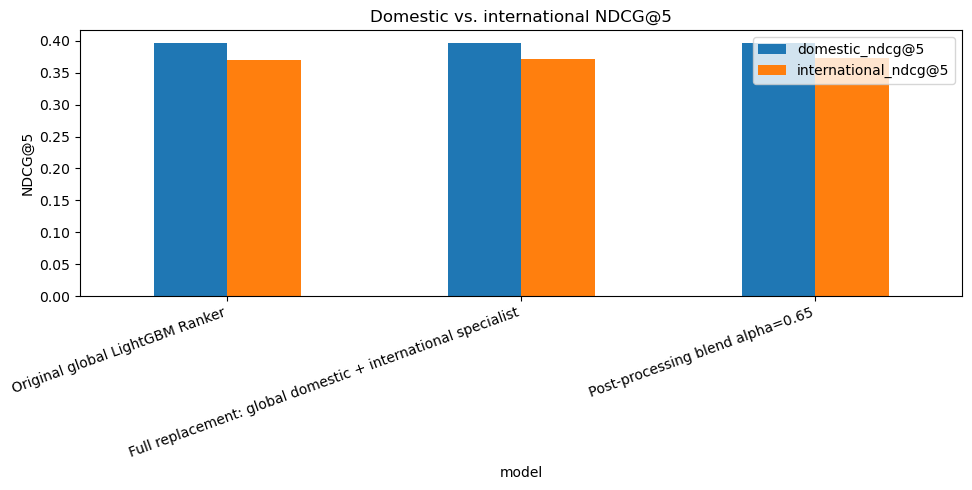

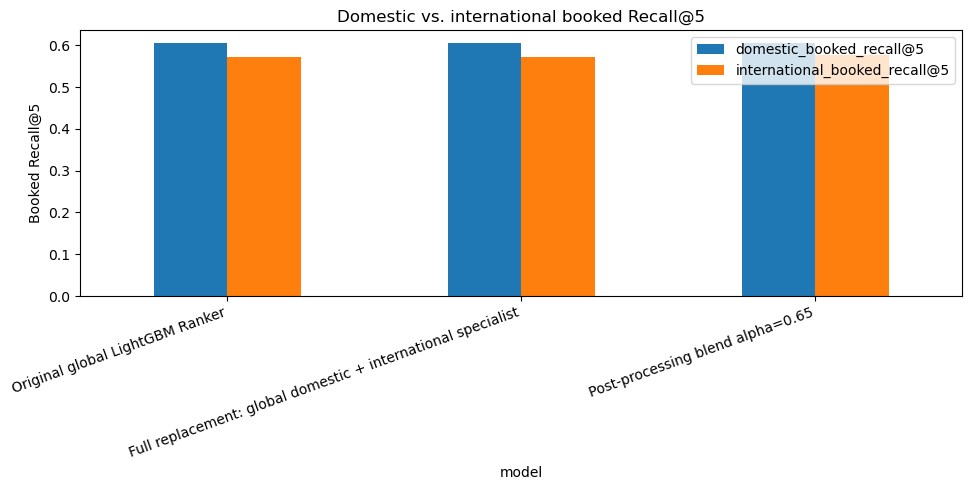

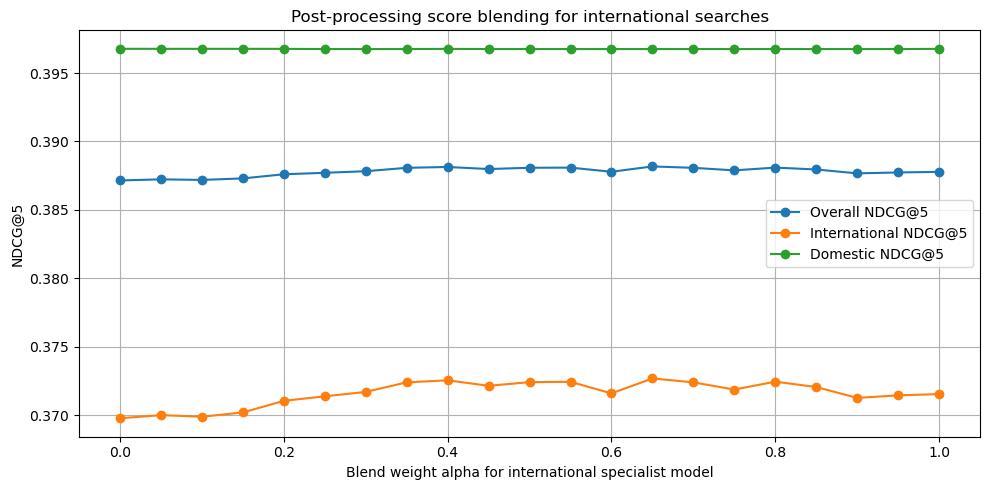

In [21]:
# ---------------------------------------------------
# Cell 20: Plots for report and interpretation
# ---------------------------------------------------

plot_df = comparison.set_index("model")

ax = plot_df[["domestic_ndcg@5", "international_ndcg@5"]].plot(kind="bar", figsize=(10, 5))
plt.title("Domestic vs. international NDCG@5")
plt.ylabel("NDCG@5")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

ax = plot_df[["domestic_booked_recall@5", "international_booked_recall@5"]].plot(kind="bar", figsize=(10, 5))
plt.title("Domestic vs. international booked Recall@5")
plt.ylabel("Booked Recall@5")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(blend_results_df["alpha"], blend_results_df["overall_ndcg@5"], marker="o", label="Overall NDCG@5")
plt.plot(blend_results_df["alpha"], blend_results_df["international_ndcg@5"], marker="o", label="International NDCG@5")
plt.plot(blend_results_df["alpha"], blend_results_df["domestic_ndcg@5"], marker="o", label="Domestic NDCG@5")
plt.xlabel("Blend weight alpha for international specialist model")
plt.ylabel("NDCG@5")
plt.title("Post-processing score blending for international searches")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# ---------------------------------------------------
# Cell 21: Save result files for report
# ---------------------------------------------------

blend_results_df.to_csv("task5_blending_alpha_results.csv", index=False)
comparison.to_csv("task5_blending_comparison.csv", index=False)
recommended_group_results.to_csv("task5_blending_recommended_group_results.csv", index=False)

try:
    all_mitigations.to_csv("task5_all_domestic_international_mitigations_with_blending.csv", index=False)
except NameError:
    pass

print("Saved Task 5 blending result files.")

Saved Task 5 blending result files.


## How to interpret the result

Use the blended model only if it improves international-search performance without reducing overall NDCG too much.

Good signs:
- `international_ndcg@5` increases compared with the original global model.
- `international_booked_recall@5` increases.
- `international_minus_domestic_ndcg@5` becomes less negative.
- `overall_ndcg@5` stays close to or above the original model.

If a middle alpha works better than `alpha = 1.0`, that means the global model and international specialist contain complementary information. In the report, describe this as a **post-processing mitigation**, because it adjusts prediction scores after training rather than changing the training data.